<a href="https://colab.research.google.com/github/psy0635-ctrl/OpenCv/blob/main/%EC%98%81%EC%83%81%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5%EC%B2%98%EB%A6%AC_0407.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

근방 처리 결과:


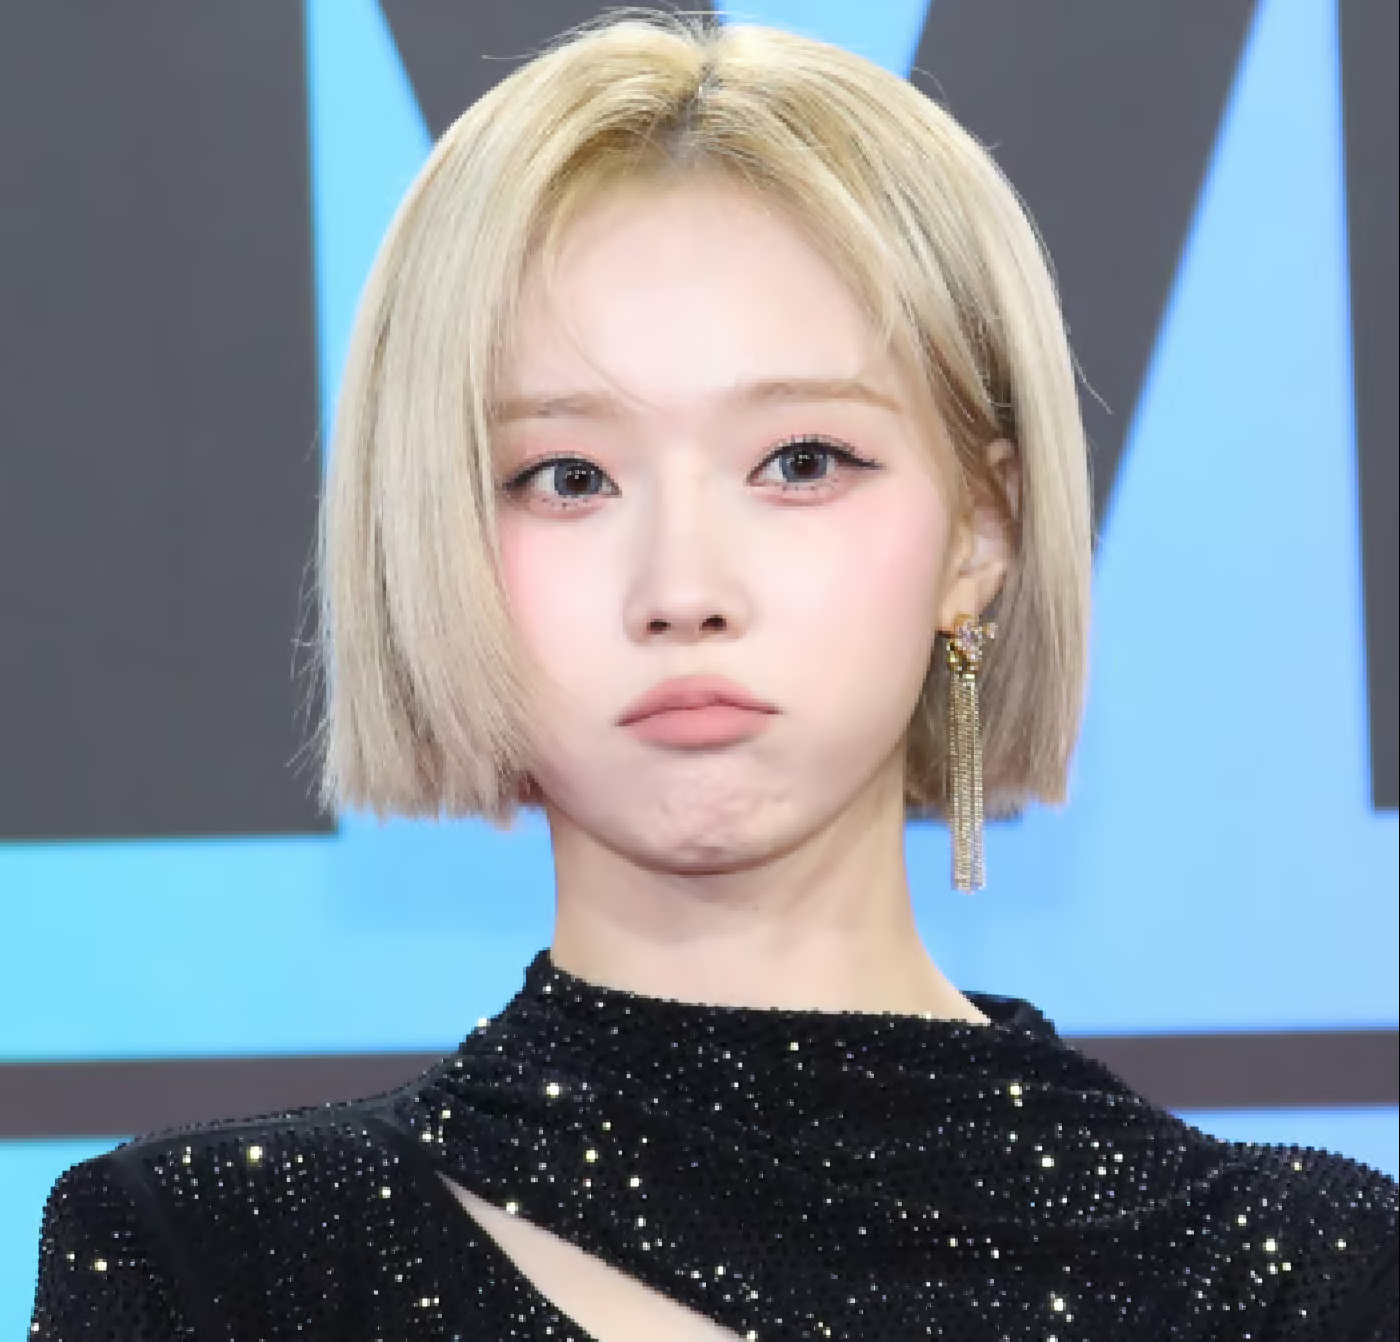

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

# 근방 처리 (Nearest Neighbor)
def manual_nearest_neighbor(img, new_h, new_w):  # “이미지를 원하는 크기로 확대하는 함수”
    old_h, old_w = img.shape[:2]                 # old_h → 원본 높이 / old_w → 원본 너비
    result = np.zeros((new_h, new_w, 3), dtype=np.uint8)  # new_h, new_w → 확대된 크기 , 3 → RGB 색상

    scale_x = old_w / new_w
    scale_y = old_h / new_h                 #“결과 좌표 → 원본 좌표로 되돌리는 공식”

    for y_prime in range(new_h):           # 확대된 이미지의 모든 좌표를 하나씩 돌면서 채움
        for x_prime in range(new_w):
            fx, fy = x_prime * scale_x, y_prime * scale_y     # 확대된 좌표 → 원본 좌표로 변환
            x, y = int(round(fx)), int(round(fy))     # 여기서“근방(Nearest)”등장 --> “대충 가장 가까운 점 찍는다” 느낌

            if 0 <= x < old_w and 0 <= y < old_h:
                result[y_prime, x_prime] = img[y, x]   # 원본 픽셀 값을 그대로 복사해서 넣음
    return result

# --- 여기에 본인 이미지 파일명을 넣으세요 ---
file_path = '/content/winter.png' # 예: 'dog.jpg', 'test.png' 등
src = cv2.imread(file_path)             # 이미지 읽기

if src is not None:
    # 2배 확대 예시
    h, w = src.shape[:2]
    output = manual_nearest_neighbor(src, h * 2, w * 2)

    print("근방 처리 결과:")
    cv2_imshow(output)
else:
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")

보간 처리 결과:


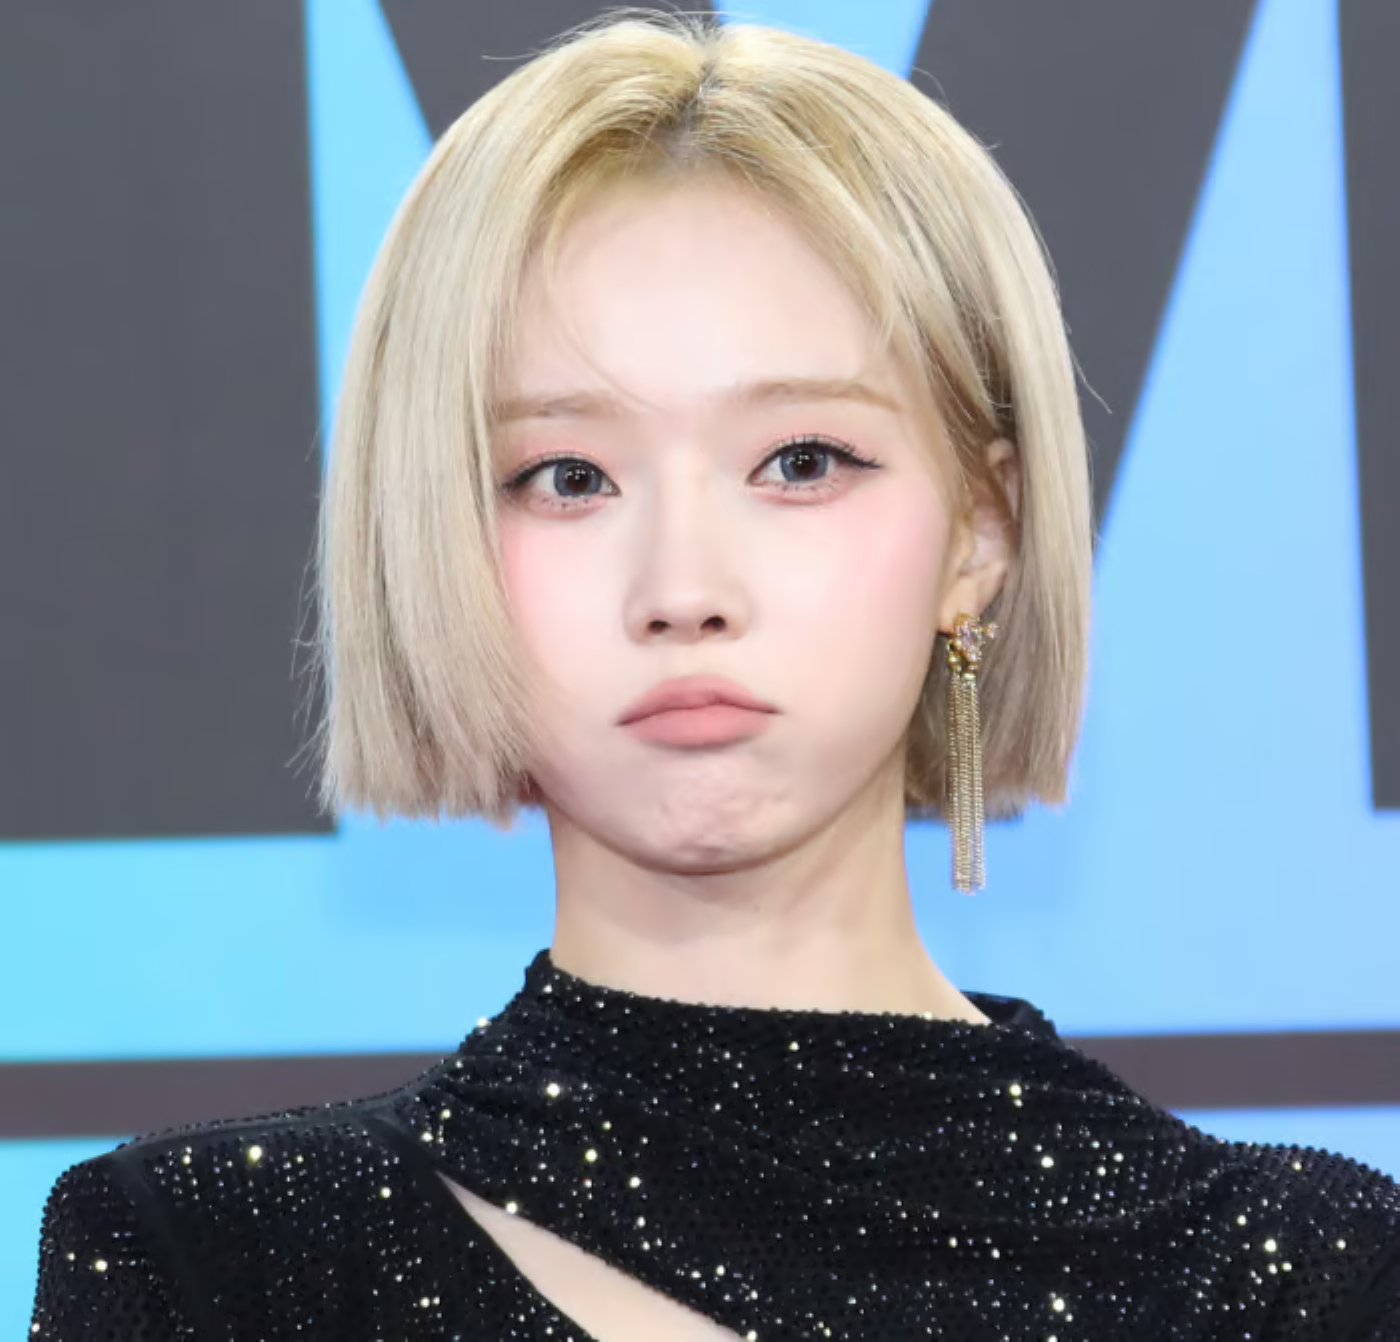

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

# 보간 처리 (Bilinear Interpolation)
def manual_bilinear_interpolation(img, new_h, new_w):  #“이미지를 원하는 크기로 확대하는 함수”
    old_h, old_w = img.shape[:2]                        # old_h, old_w → 원본 크기
    result = np.zeros((new_h, new_w, 3), dtype=np.float32)  # result → 결과 이미지 (빈 도화지)

    scale_x = old_w / new_w
    scale_y = old_h / new_h

    for y_prime in range(new_h):
        for x_prime in range(new_w):
            fx, fy = x_prime * scale_x, y_prime * scale_y
            x1, y1 = int(fx), int(fy)
            x2, y2 = min(x1 + 1, old_w - 1), min(y1 + 1, old_h - 1)

            p, q = fx - x1, fy - y1

            pixel_val = (
                (1 - p) * (1 - q) * img[y1, x1] +
                p * (1 - q) * img[y1, x2] +
                (1 - p) * q * img[y2, x1] +
                p * q * img[y2, x2]
            )
            result[y_prime, x_prime] = pixel_val

    return result.astype(np.uint8)

# --- 여기에 본인 이미지 파일명을 넣으세요 ---
file_path = '/content/winter.png'
src = cv2.imread(file_path)

if src is not None:
    h, w = src.shape[:2]
    output = manual_bilinear_interpolation(src, h * 2, w * 2)

    print("보간 처리 결과:")
    cv2_imshow(output)

원본 이미지 불러오기 성공 (크기: (671, 700))

[계산 중...] 근방 처리(Nearest Neighbor)
[계산 중...] 보간 처리(Bilinear Interpolation)

--- 결과 비교 ---
1. 원본 그레이 스케일 (보기 편하게 2배 키워서 출력):


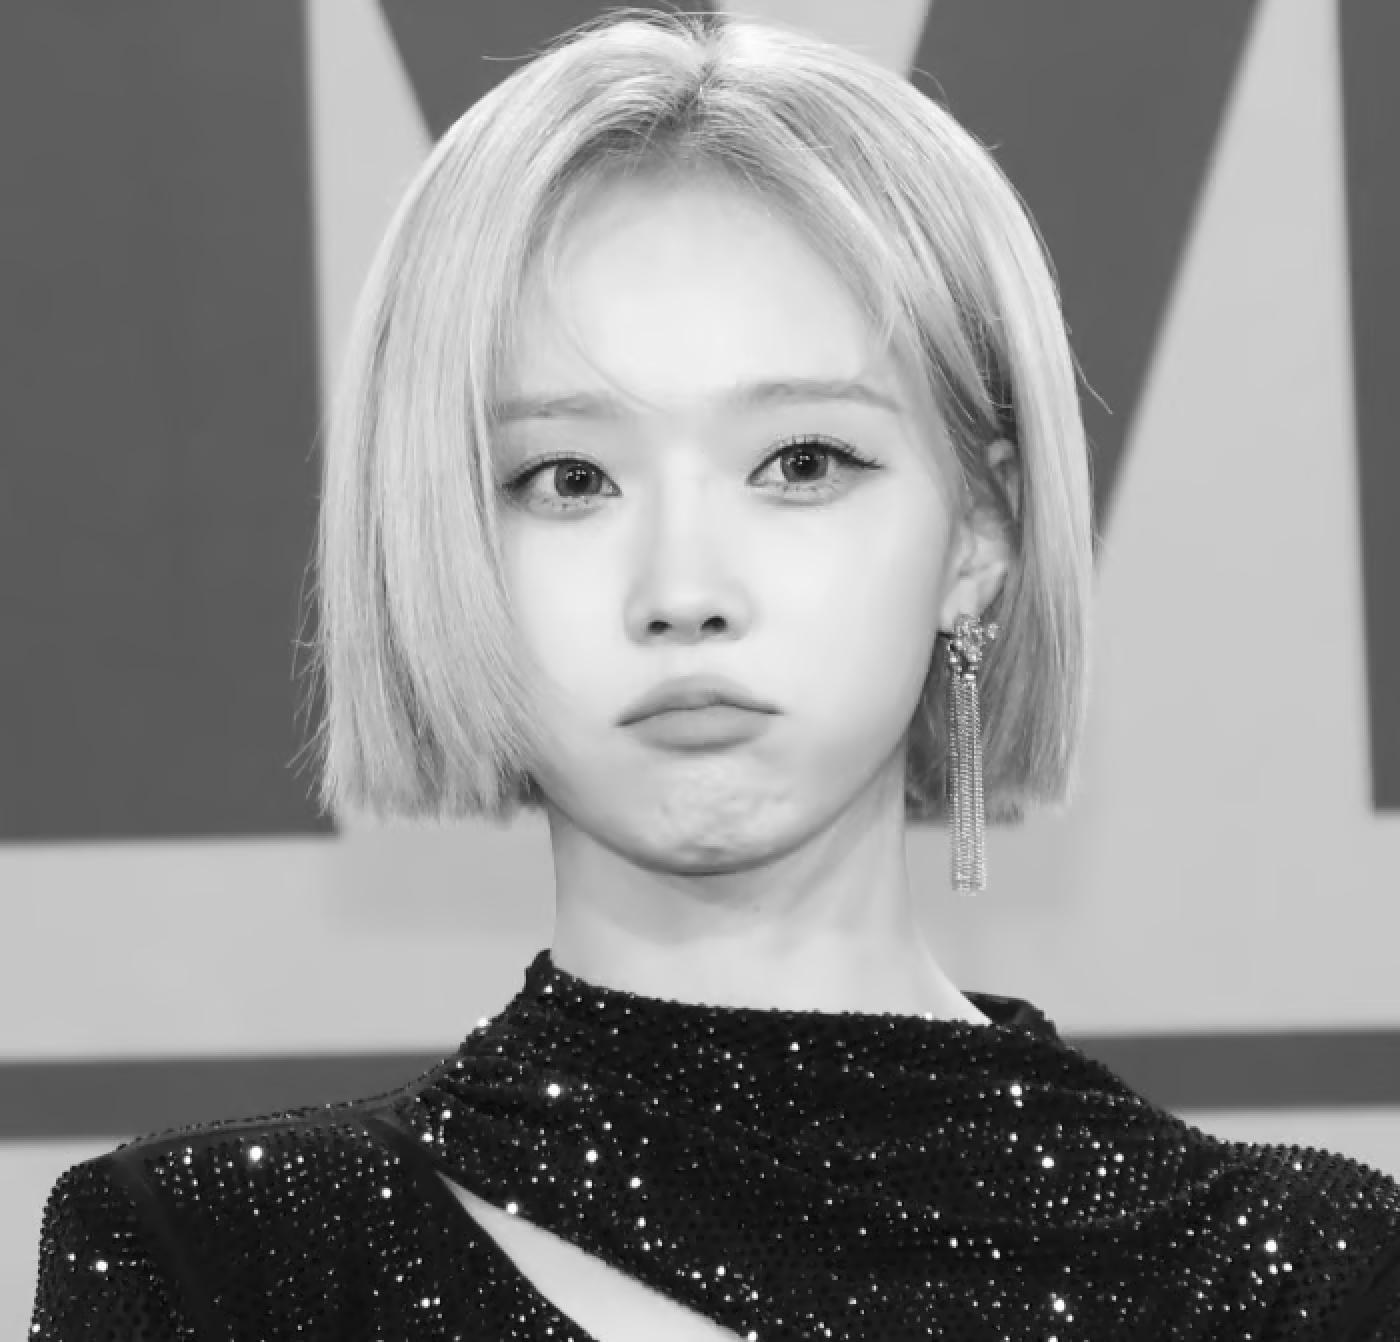


2. 근방 처리 결과 (3배 확대, 계단 현상 확인):


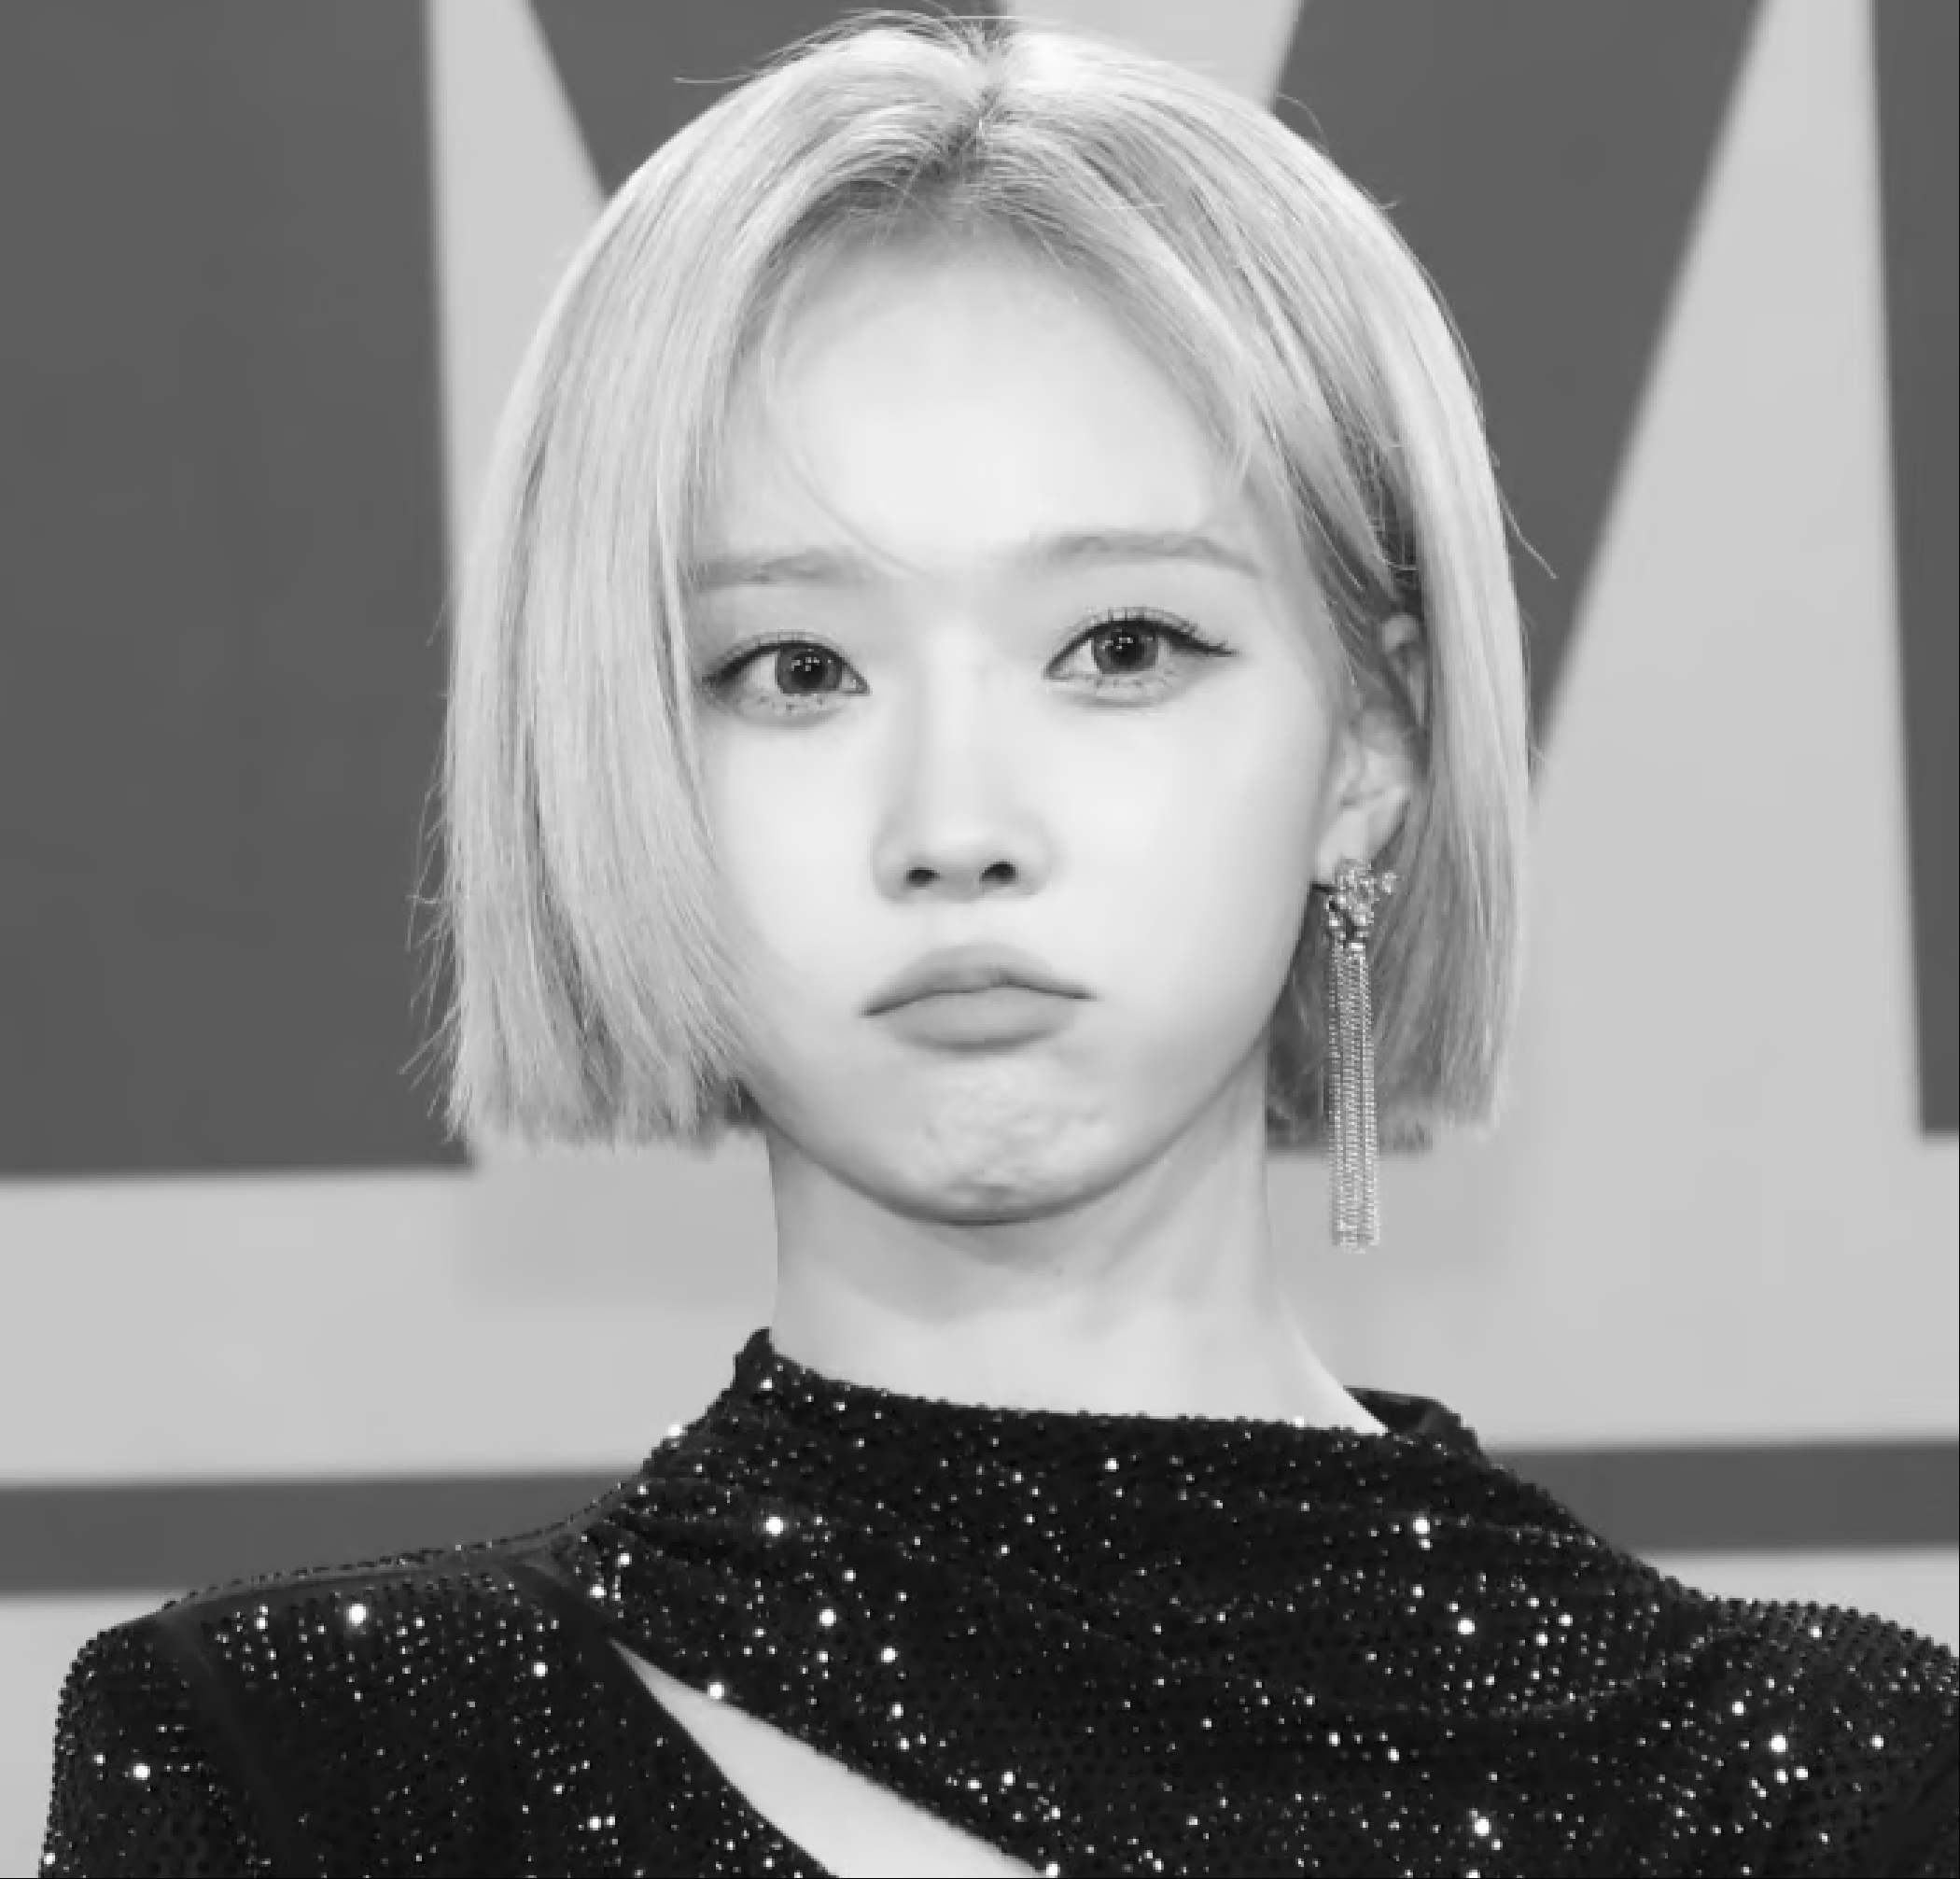


3. 보간 처리 결과 (3배 확대, 부드러운 경계 확인):


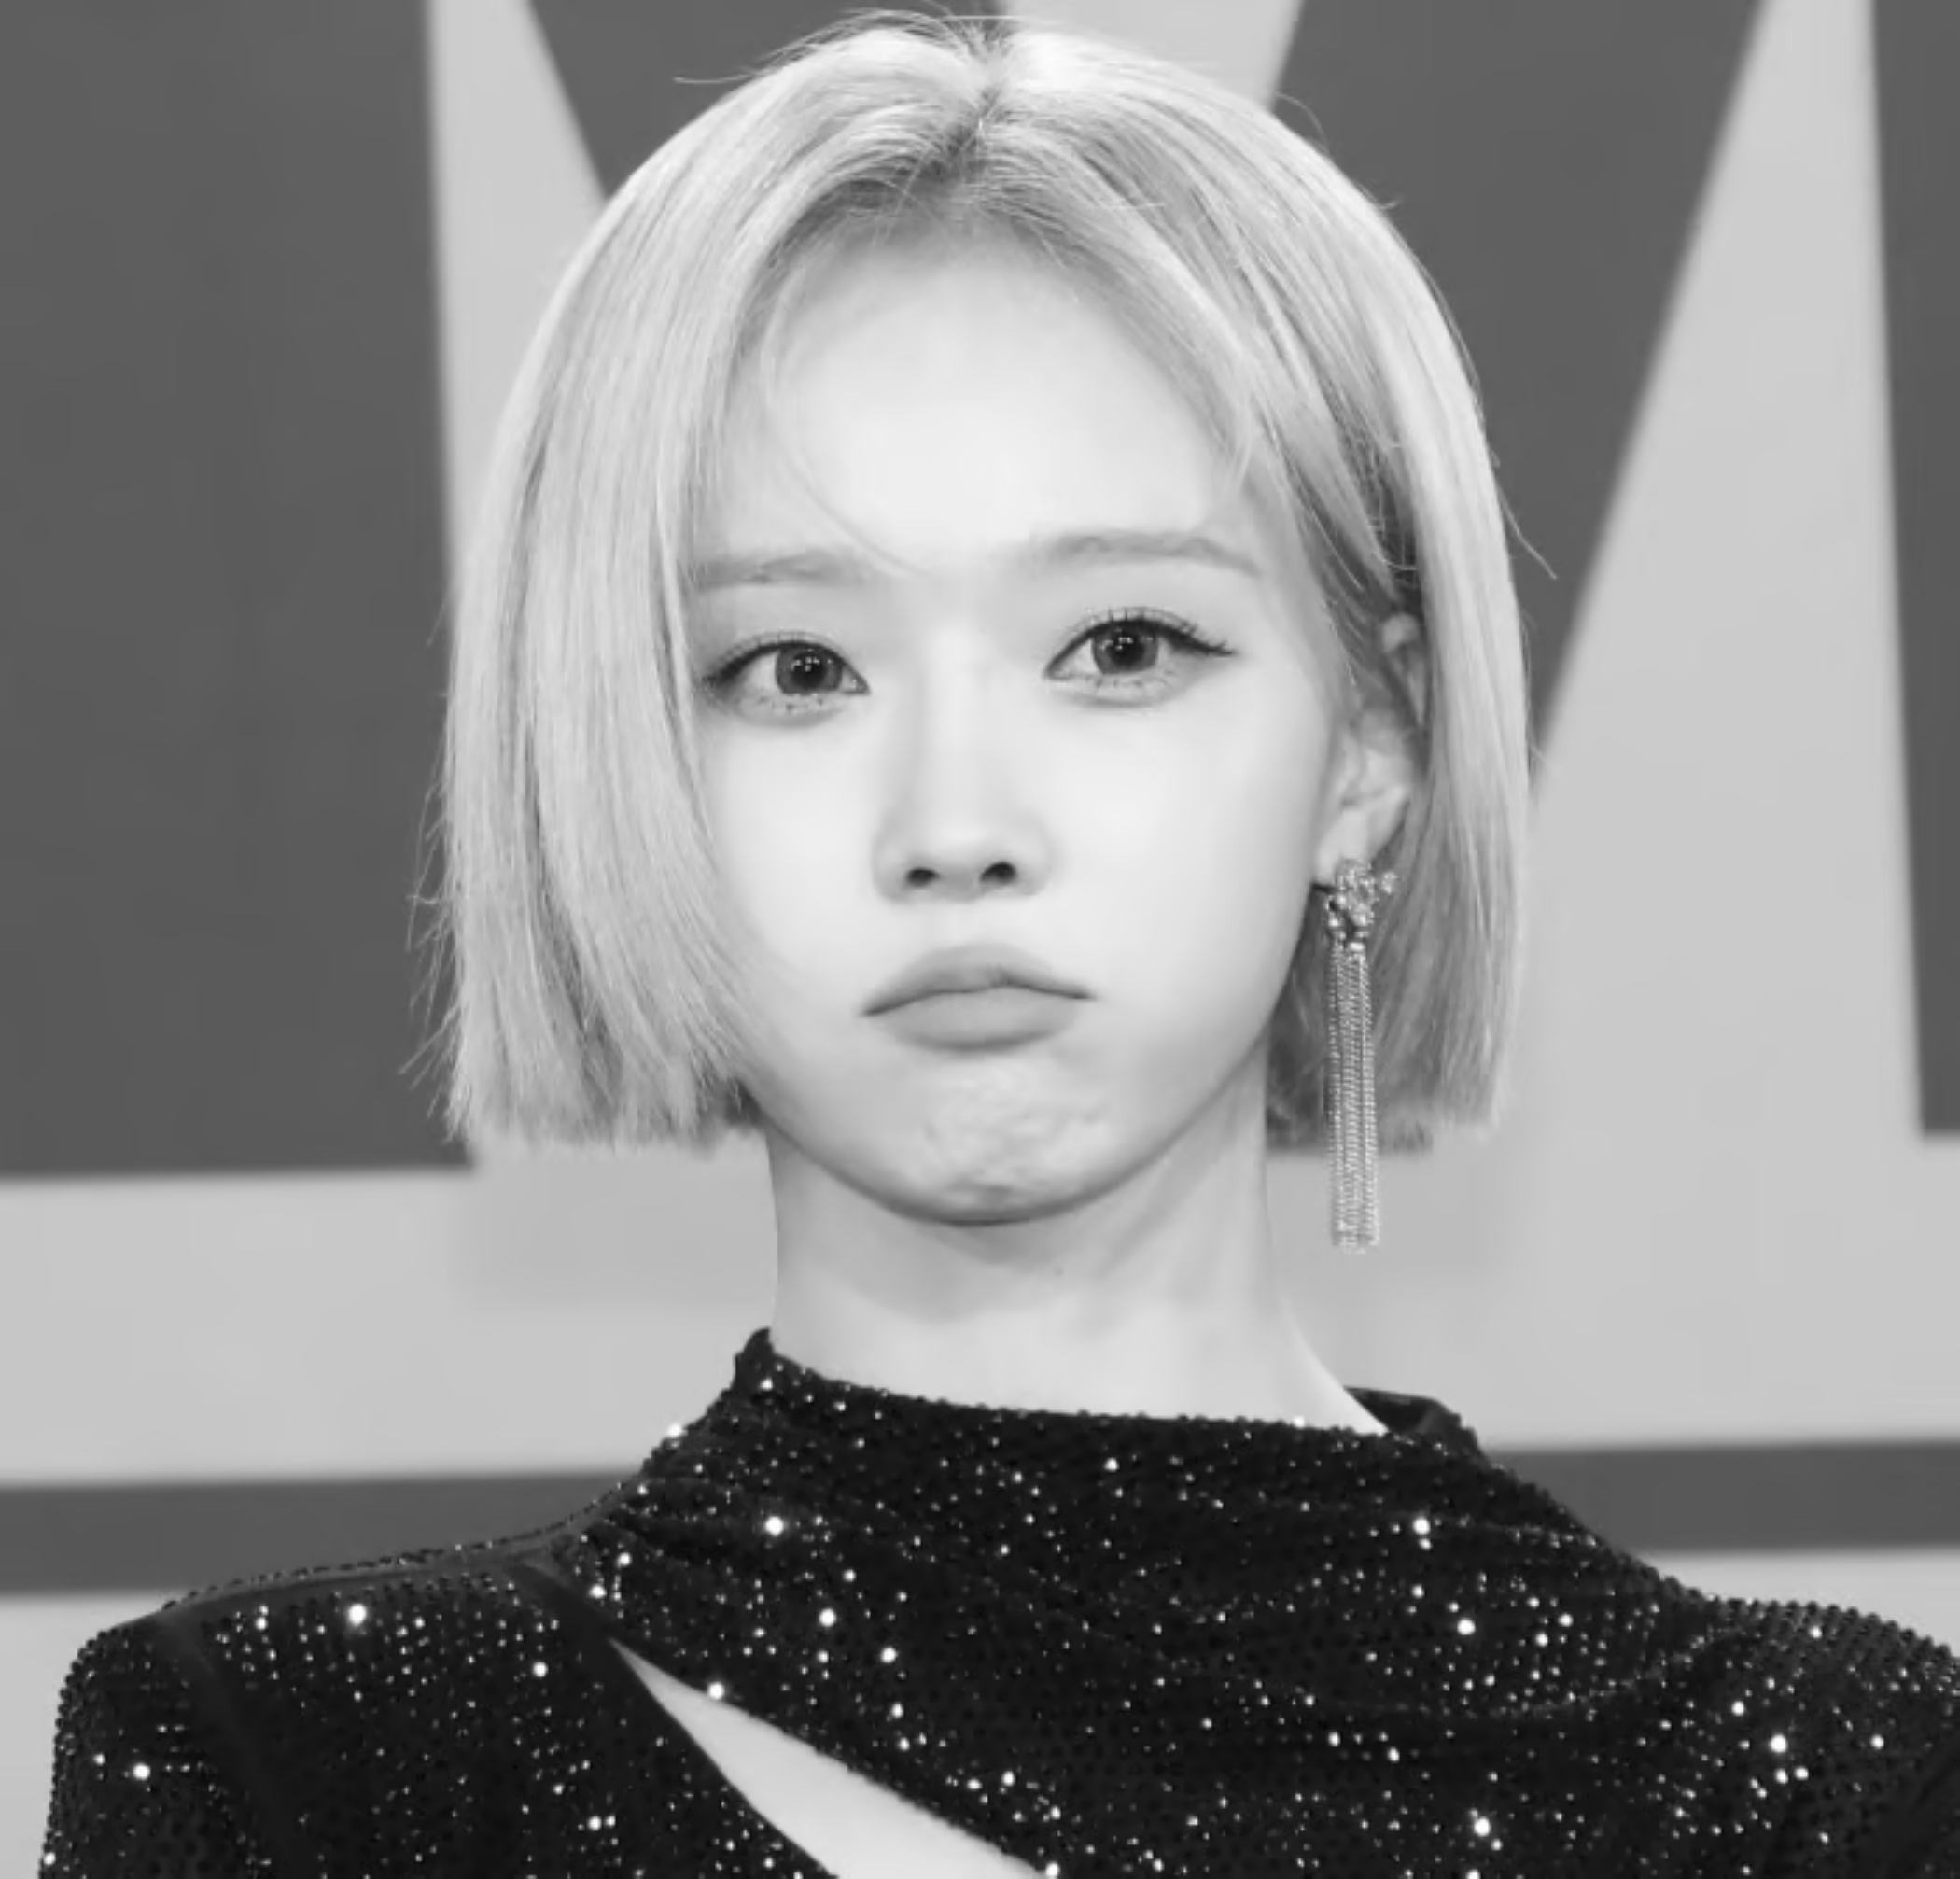

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

# --- 공통 함수: 그레이 스케일로 이미지 불러오기 ---
def load_grayscale_image(file_path):
    # cv2.IMREAD_GRAYSCALE 옵션을 주면 흑백으로 불러옵니다.
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"파일을 찾을 수 없습니다: {file_path}")
        return None
    print(f"원본 이미지 불러오기 성공 (크기: {img.shape})")
    return img

# --- 1. 근방 처리 (Nearest Neighbor) 구현 ---
def manual_nearest_neighbor_gray(img, new_h, new_w):
    old_h, old_w = img.shape
    # 그레이 스케일이므로 채널 없이 (H, W) 형태의 빈 이미지를 만듭니다.
    result = np.zeros((new_h, new_w), dtype=np.uint8)

    scale_x = old_w / new_w
    scale_y = old_h / new_h

    for y_prime in range(new_h):
        for x_prime in range(new_w):
            fx, fy = x_prime * scale_x, y_prime * scale_y
            # 반올림으로 가장 가까운 정수 좌표 찾기
            x, y = int(round(fx)), int(round(fy))

            # 범위 체크 후 값 할당
            if 0 <= x < old_w and 0 <= y < old_h:
                result[y_prime, x_prime] = img[y, x]
    return result

# --- 2. 보간 처리 (Bilinear Interpolation) 구현 ---
def manual_bilinear_interpolation_gray(img, new_h, new_w):
    old_h, old_w = img.shape
    # 계산을 위해 float32형으로 빈 이미지를 만듭니다.
    result = np.zeros((new_h, new_w), dtype=np.float32)

    scale_x = old_w / new_w
    scale_y = old_h / new_h

    for y_prime in range(new_h):
        for x_prime in range(new_w):
            fx, fy = x_prime * scale_x, y_prime * scale_y
            x1, y1 = int(fx), int(fy)
            x2, y2 = min(x1 + 1, old_w - 1), min(y1 + 1, old_h - 1)

            p, q = fx - x1, fy - y1

            # 그레이 스케일이므로 픽셀 값이 단일 숫자입니다. 계산이 더 단순해집니다.
            pixel_val = (
                (1 - p) * (1 - q) * img[y1, x1] +
                p * (1 - q) * img[y1, x2] +
                (1 - p) * q * img[y2, x1] +
                p * q * img[y2, x2]
            )
            result[y_prime, x_prime] = pixel_val

    # 최종 출력은 다시 uint8로 변환합니다.
    return result.astype(np.uint8)

# --- 메인 실행 부분 ---
# 1. 이미지 경로 설정 (본인의 파일명으로 수정 가능)
file_path = '/content/winter.png'

# 2. 그레이 스케일 원본 불러오기
src_gray = load_grayscale_image(file_path)

if src_gray is not None:
    # 3. 확대 크기 설정 (3배 확대)
    h, w = src_gray.shape
    new_h, new_w = h * 3, w * 3

    # 4. 두 가지 방식으로 확대 실행
    print("\n[계산 중...] 근방 처리(Nearest Neighbor)")
    res_nearest = manual_nearest_neighbor_gray(src_gray, new_h, new_w)

    print("[계산 중...] 보간 처리(Bilinear Interpolation)")
    res_bilinear = manual_bilinear_interpolation_gray(src_gray, new_h, new_w)

    # 5. 결과 출력 및 비교
    print("\n--- 결과 비교 ---")
    print("1. 원본 그레이 스케일 (보기 편하게 2배 키워서 출력):")
    cv2_imshow(cv2.resize(src_gray, (w*2, h*2), interpolation=cv2.INTER_NEAREST))

    print("\n2. 근방 처리 결과 (3배 확대, 계단 현상 확인):")
    cv2_imshow(res_nearest)

    print("\n3. 보간 처리 결과 (3배 확대, 부드러운 경계 확인):")
    cv2_imshow(res_bilinear)

OpenCV 함수 이용 회전 결과:


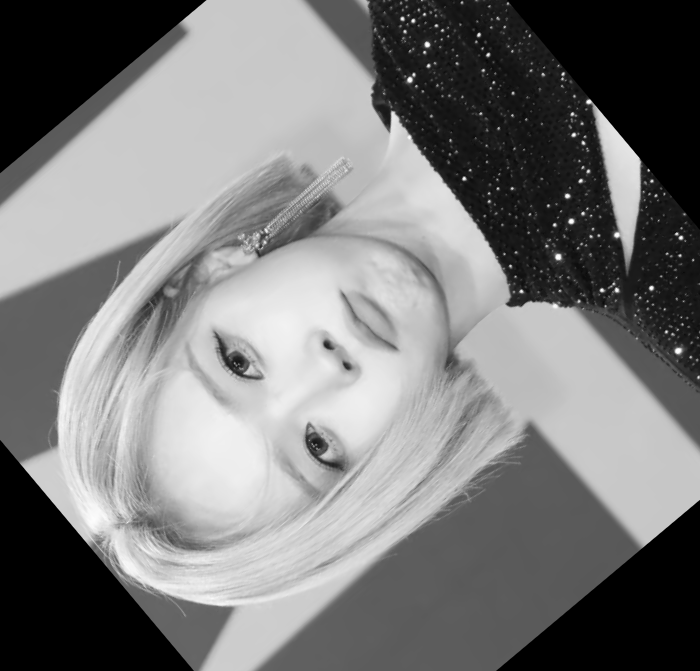

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 1. 이미지 읽기 (그레이스케일 모드)
src = cv2.imread('/content/winter.png', cv2.IMREAD_GRAYSCALE)

if src is not None:   # 이미지의 세로(h), 가로(w) 크기를 가져옵니다
    h, w = src.shape

   # 2. 회전의 중심점 설정 (이미지 가이드의 128, 128 역할)
    # 이미지 가로/세로의 딱 중간 지점을 회전축으로 잡습니다.
    cx, cy = w // 2, h // 2

# 3. 회전 변환 행렬(M) 만들기
    # getRotationMatrix2D(중심점, 회전각도, 확대배율)
    # 각도 45: 반시계 방향으로 45도 회전 / 1.0: 크기 유지
    M = cv2.getRotationMatrix2D(center=(cx, cy), angle=130, scale=1.0)

# 4. 실제로 이미지 돌리기 (아핀 변환 적용)
    # warpAffine(원본, 변환행렬, 결과크기, 빈칸채울색상)
    # 이미지를 돌리고 남은 빈 공간은 검정색(0)으로 채웁니다.
    dst = cv2.warpAffine(src, M, (w, h), borderValue=0)

    print("OpenCV 함수 이용 회전 결과:")
    cv2_imshow(dst)

수식 직접 구현 회전 결과:


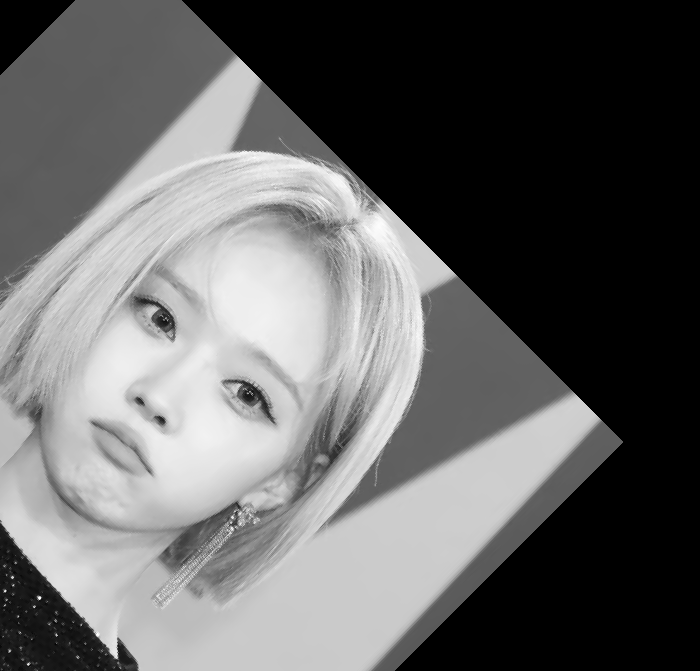

In [ ]:
import cv2
import numpy as np
import math   # 삼각함수(cos, sin) 사용을 위해 필요
from google.colab.patches import cv2_imshow

def manual_rotate(img, angle):
    old_h, old_w = img.shape
    # 결과가 담길 빈 도화지를 만듭니다.
    result = np.zeros((old_h, old_w), dtype=np.uint8)

    # 1. 회전 중심점 설정 (이미지 가이드 기준 128)
    cx, cy = 128, 128

    # 2. 각도를 컴퓨터가 이해하는 라디안 값으로 변환
    # 컴퓨터는 '도(degree)'가 아니라 '라디안' 단위를 사용합니다
    theta = math.radians(angle)
    cos_t = math.cos(theta)
    sin_t = math.sin(theta)

    # 3. 결과 이미지의 모든 칸(픽셀)을 하나씩 방문합니다.
    for y_prime in range(old_h):
        for x_prime in range(old_w):

    # --- 역방향 연산 시작 ---
    # "지금 결과창의 (x_prime, y_prime) 칸에 채울 색은 원본의 어디서 왔을까?"

            # 이미지 가이드에 적힌 공식 그대로 적용
            fx = (x_prime - cx) * cos_t + (y_prime - cy) * sin_t + cx
            fy = (y_prime - cy) * cos_t - (x_prime - cx) * sin_t + cy

            # 4. 근방 처리 (가장 가까운 정수 좌표 찾기)
            # 계산된 좌표 fx, fy는 소수점이므로 반올림해서 픽셀 위치를 결정합니다.
            x, y = int(round(fx)), int(round(fy))

            # 5. 찾은 좌표가 원본 이미지 범위 안에 있는지 확인
            # 범위를 벗어난 곳은 그냥 검정색(초기값 0)으로 둡니다.
            if 0 <= x < old_w and 0 <= y < old_h:
                result[y_prime, x_prime] = img[y, x]

    return result

# 실행 코드
src = cv2.imread('/content/winter.png', cv2.IMREAD_GRAYSCALE)
if src is not None:
    # 45도 회전 테스트
    rotated_img = manual_rotate(src, 45)

    print("수식 직접 구현 회전 결과:")
    cv2_imshow(rotated_img)

--- 원본 이미지 ---


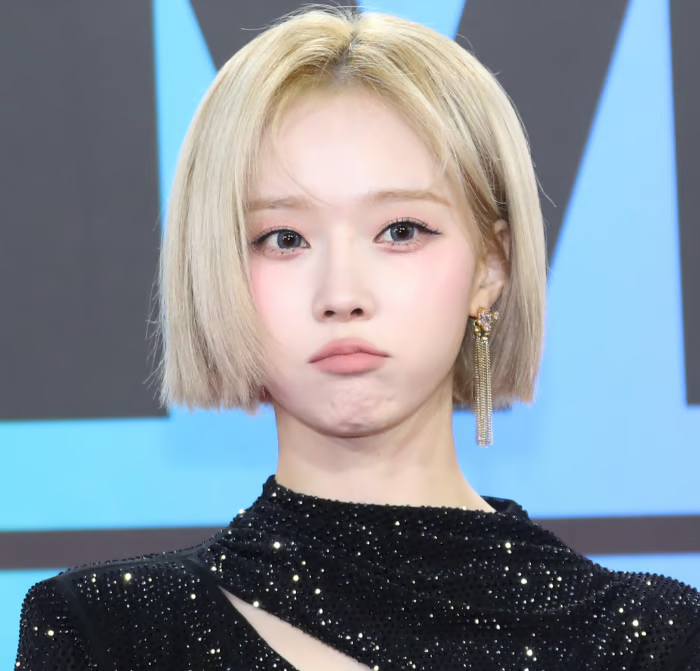


--- (1) 거울 반사 (좌우 반전: flipCode=1) ---


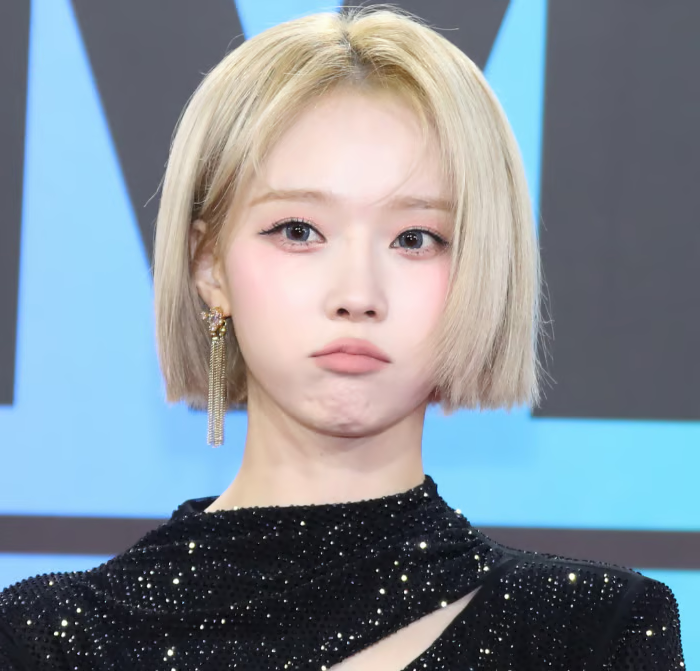


--- (2) 플립 (상하 반전: flipCode=0) ---


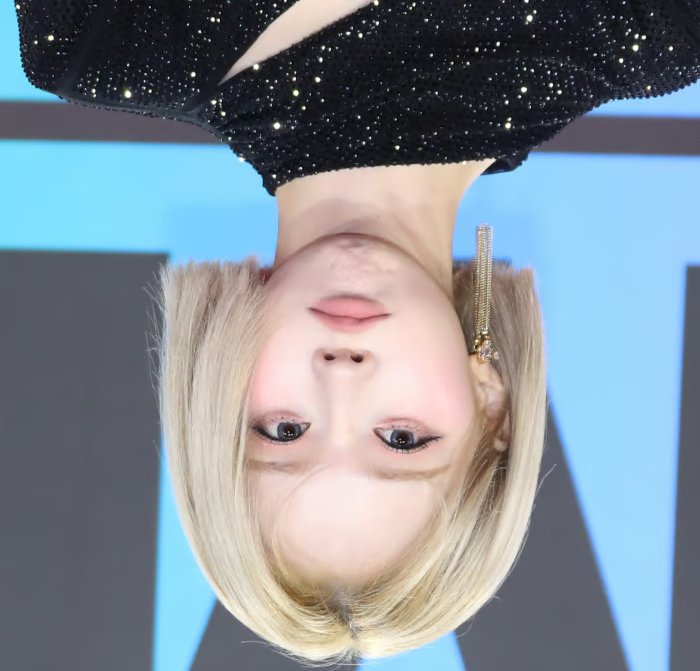


--- (3) 동시 반전 (flipCode=-1) ---


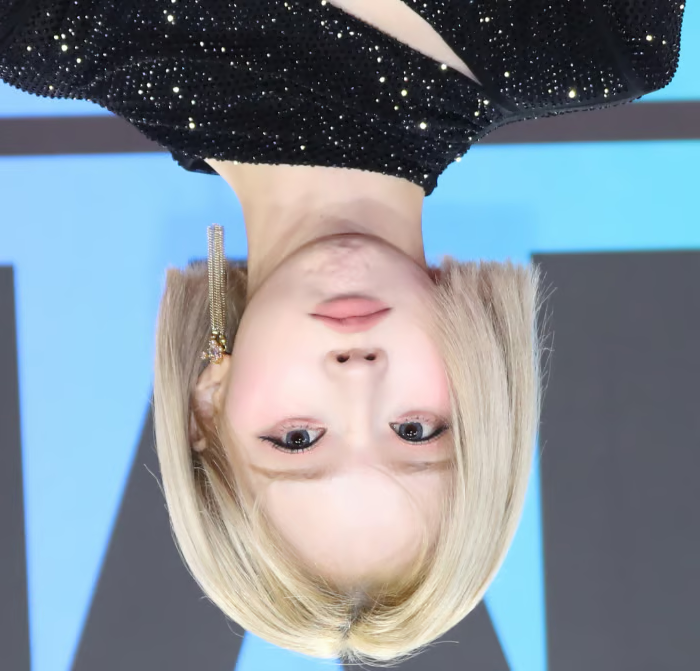

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 1. 이미지 읽기
src = cv2.imread('/content/winter.png')

if src is not None:
    # (1) 거울 반사 (좌우 반전, flipCode = 1)
    mirror = cv2.flip(src, 1)

    # (2) 플립 (상하 반전, flipCode = 0)
    flip_v = cv2.flip(src, 0)

    # (3) 좌우 + 상하 동시 반전 (flipCode = -1)
    both = cv2.flip(src, -1)

    # 결과 출력
    print("--- 원본 이미지 ---")
    cv2_imshow(src)

    print("\n--- (1) 거울 반사 (좌우 반전: flipCode=1) ---")
    cv2_imshow(mirror)

    print("\n--- (2) 플립 (상하 반전: flipCode=0) ---")
    cv2_imshow(flip_v)

    print("\n--- (3) 동시 반전 (flipCode=-1) ---")
    cv2_imshow(both)
else:
    print("이미지를 불러오지 못했습니다. 경로를 확인해주세요.")